# EsGB 黑洞几何吸收截面 $\sigma_{\text{geo}}$

计算大质量粒子的测地线几何吸收截面。对于质量 $\mu$、能量 $E=\omega$ 的粒子，
定义 $v = \sqrt{1 - \mu^2/\omega^2}$，求解临界碰撞参数 $b_c$ 和临界半径 $r_c$：

$$r_c A'(r_c) = 2A(r_c)\left[1 - (1-v^2)A(r_c)\right] \quad (\text{方程2：确定 } r_c)$$

$$\frac{r_c^2}{A(r_c)}\left[1 - (1-v^2)A(r_c)\right] = v^2 b_c^2 \quad (\text{方程1：确定 } b_c)$$

$$\sigma_{\text{geo}} = \pi b_c^2$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import importlib, esgb_solver_core as core; importlib.reload(core)

# ══════════════════════════════════════════════════════════════════
# 参数设置
rh         = 1.0
alpha      = 0.35
phi_h_init = 1.183
N          = 19

# ── 选择耦合函数（二选一） ──────────────────────────────────────
# 多项式耦合 f(φ) = φ² + βφ⁴
# coupling = core.PolynomialCoupling(beta=-0.6)

# 指数耦合 f(φ) = 1 - e^{-βφ²}
coupling = core.ExponentialCoupling(beta=3.0)
# ══════════════════════════════════════════════════════════════════

sol = core.solve(rh=rh, alpha=alpha, coupling=coupling,
                 phi_h_init=phi_h_init, N=N, verbose=True)
print(sol)
print(f"M_ADM = {sol.M_ADM:.6f}")

# 度规函数
A_func = sol.gtt_at       # A(r)
dA_func = sol.dgtt_dr     # A'(r)

[OK]  alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.10297, M=0.62516, Q=0.83384, ||R||=8.59e-13
EsGBSolution(converged, alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.1030, M=0.6252, Q=0.8338, ||R||=8.59e-13)
M_ADM = 0.625164


In [2]:
def solve_rc_bc(A, dA, v, rh, r_guess_factor=1.5):
    """
    求解临界半径 r_c 和临界碰撞参数 b_c。
    
    参数
    ----
    A, dA : callable, 度规函数 A(r) 及其导数
    v     : 粒子速度 v = sqrt(1 - mu^2/omega^2)
    rh    : 视界半径
    
    返回
    ----
    r_c, b_c, sigma_geo
    """
    w = 1.0 - v**2   # = mu^2 / omega^2
    
    # 方程 (2): r_c A'(r_c) - 2 A(r_c) [1 - w A(r_c)] = 0
    def eq2(r):
        Ar = A(r)
        dAr = dA(r)
        return r * dAr - 2.0 * Ar * (1.0 - w * Ar)
    
    # 在 (rh, r_max) 范围内搜索根
    # r_c 应该在视界外侧不远处（不稳定圆轨道）
    r_min_search = rh * 1.001
    r_max_search = rh * 30.0
    
    # 用细密扫描找到变号区间
    r_scan = np.linspace(r_min_search, r_max_search, 5000)
    f_scan = np.array([eq2(r) for r in r_scan])
    
    # 找所有变号点，取最靠近视界的（不稳定圆轨道）
    sign_changes = np.where(np.diff(np.sign(f_scan)))[0]
    if len(sign_changes) == 0:
        return np.nan, np.nan, np.nan
    
    # 取最靠近视界的根
    idx = sign_changes[0]
    r_c = brentq(eq2, r_scan[idx], r_scan[idx + 1], xtol=1e-12)
    
    # 方程 (1): b_c^2 = r_c^2 / (v^2 A(r_c)) * [1 - w A(r_c)]
    Ar_c = A(r_c)
    factor = 1.0 - w * Ar_c
    if factor <= 0 or v == 0:
        return np.nan, np.nan, np.nan
    
    bc_sq = r_c**2 / (v**2 * Ar_c) * factor
    if bc_sq < 0:
        return np.nan, np.nan, np.nan
    
    b_c = np.sqrt(bc_sq)
    sigma_geo = np.pi * bc_sq
    
    return r_c, b_c, sigma_geo


# ── 验证：Schwarzschild 无质量极限 ──
# A(r) = 1 - rh/r, 解析结果: r_c = 3rh/2, b_c^2 = 27rh^2/4
A_schw = lambda r: 1.0 - rh / r
dA_schw = lambda r: rh / r**2

r_c_test, b_c_test, sig_test = solve_rc_bc(A_schw, dA_schw, v=1.0, rh=rh)
print(f"Schwarzschild v=1: r_c = {r_c_test:.6f} (解析: {1.5*rh:.6f})")
print(f"  b_c^2 = {b_c_test**2:.6f} (解析: {27*rh**2/4:.6f})")
print(f"  sigma_geo = {sig_test:.6f} (解析: {27*np.pi*rh**2/4:.6f})")

Schwarzschild v=1: r_c = 1.500000 (解析: 1.500000)
  b_c^2 = 6.750000 (解析: 6.750000)
  sigma_geo = 21.205750 (解析: 21.205750)


In [3]:
# ── 扫描 omega，计算几何吸收截面 ──

M = sol.M_ADM            # EsGB 黑洞的 ADM 质量
M_schw = rh / 2.0        # Schwarzschild 的质量 (rh=1 时 M=0.5)

mu_M = 0.0               # 无量纲粒子质量 μ·M
mu_esgb = mu_M / M       # 对应 EsGB 的 μ（坐标单位）
mu_schw = mu_M / M_schw  # 对应 Schwarzschild 的 μ

# Mω 扫描范围
Momega_arr = np.linspace(1, 12.0, 200)

# ── EsGB ──
sigma_esgb = []
rc_esgb = []
for Mw in Momega_arr:
    omega = Mw / M
    if omega <= mu_esgb:
        sigma_esgb.append(np.nan)
        rc_esgb.append(np.nan)
        continue
    v = np.sqrt(1.0 - (mu_esgb / omega)**2)
    r_c, b_c, sig = solve_rc_bc(A_func, dA_func, v, rh)
    sigma_esgb.append(sig)
    rc_esgb.append(r_c)

sigma_esgb = np.array(sigma_esgb)

# ── Schwarzschild ──
sigma_schw = []
for Mw in Momega_arr:
    omega = Mw / M_schw
    if omega <= mu_schw:
        sigma_schw.append(np.nan)
        continue
    v = np.sqrt(1.0 - (mu_schw / omega)**2)
    r_c, b_c, sig = solve_rc_bc(A_schw, dA_schw, v, rh)
    sigma_schw.append(sig)

sigma_schw = np.array(sigma_schw)

print(f"EsGB: M_ADM = {M:.4f}, μ = {mu_esgb:.4f}")
print(f"Schwarzschild: M = {M_schw:.4f}, μ = {mu_schw:.4f}")
print(f"μM = {mu_M}")

EsGB: M_ADM = 0.6252, μ = 0.0000
Schwarzschild: M = 0.5000, μ = 0.0000
μM = 0.0


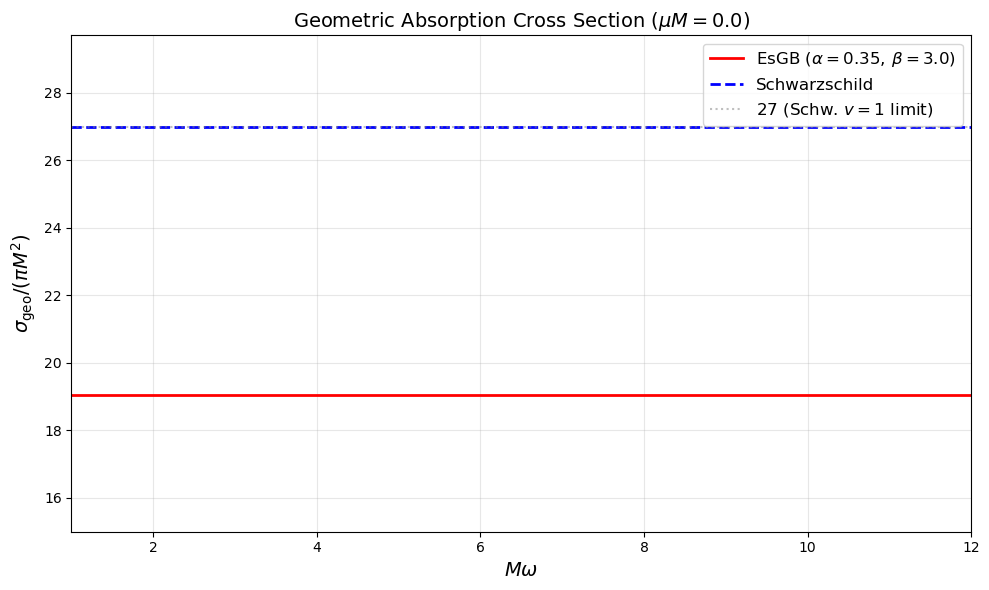

In [4]:
# ── 画图 ──
fig, ax = plt.subplots(figsize=(10, 6))

# 无量纲化：σ_geo / (π M²)
y_esgb = sigma_esgb / (np.pi * M**2)
y_schw = sigma_schw / (np.pi * M_schw**2)

ax.plot(Momega_arr, y_esgb, 'r-', lw=2,
        label=rf'EsGB ($\alpha={alpha},\,{sol.coupling.label_str()}$)')

ax.plot(Momega_arr, y_schw, 'b--', lw=2,
        label='Schwarzschild')

# 高频极限参考线：Schwarzschild 无质量粒子 σ_geo = 27πM²，即 σ/(πM²) = 27
ax.axhline(y=27, color='gray', ls=':', alpha=0.5, label=r'$27$ (Schw. $v=1$ limit)')

ax.set_xlabel(r'$M\omega$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\mathrm{geo}} / (\pi M^2)$', fontsize=14)
ax.set_title(rf'Geometric Absorption Cross Section ($\mu M = {mu_M}$)', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim(Momega_arr[0], Momega_arr[-1])

# 纵轴范围：下限自适应，上限留余量
y_all = np.concatenate([y_esgb[np.isfinite(y_esgb)], y_schw[np.isfinite(y_schw)]])
y_min = max(np.nanmin(y_all) - 2, 0)
y_max = np.nanmax(y_all) * 1.1
if y_min > 15:
    y_min = 15
ax.set_ylim(y_min, y_max)

ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('geodesic_cross_section.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# ── 补充：无质量极限 (v=1) 的截面对比 ──
r_c_esgb_v1, b_c_esgb_v1, sig_esgb_v1 = solve_rc_bc(A_func, dA_func, v=1.0, rh=rh)
r_c_schw_v1, b_c_schw_v1, sig_schw_v1 = solve_rc_bc(A_schw, dA_schw, v=1.0, rh=rh)

print("=== 无质量极限 (v=1) ===")
print(f"Schwarzschild: r_c = {r_c_schw_v1:.4f}, b_c = {b_c_schw_v1:.4f}, "
      f"σ_geo/(πM²) = {sig_schw_v1/(np.pi*M_schw**2):.4f}")
print(f"EsGB:          r_c = {r_c_esgb_v1:.4f}, b_c = {b_c_esgb_v1:.4f}, "
      f"σ_geo/(πM²) = {sig_esgb_v1/(np.pi*M**2):.4f}")
print(f"\nσ_EsGB / σ_Schw = {sig_esgb_v1/sig_schw_v1:.4f}")

## 多组 EsGB 解 vs Schwarzschild 对比图

In [4]:
# ══════════════════════════════════════════════════════════════════
# 几何吸收截面对比图：多组 EsGB 解 vs Schwarzschild
# ══════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")
import importlib
import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import brentq

import esgb_solver_core as core; importlib.reload(core)
from esgb_solver_core import PolynomialCoupling, ExponentialCoupling

rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset' : 'stix',
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 7.5,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'xtick.top'        : True,
    'ytick.right'      : True,
    'lines.linewidth'  : 1.2,
})

# ── 参数设置 ──────────────────────────────────────────────────────
CASES = [
    dict(alpha=0.35, coupling=ExponentialCoupling(beta=2.0), phi_h_init=1.383),
    dict(alpha=0.35, coupling=ExponentialCoupling(beta=3.0), phi_h_init=1.183),
    dict(alpha=0.35, coupling=ExponentialCoupling(beta=4.0), phi_h_init=1.054),
]
rh    = 1.0
N     = 19
mu_M  = 0.4       # 无量纲粒子质量 μM（可调）

# Mω 扫描范围
Momega_arr = np.linspace(1, 6.0, 200)

# ── 绘图样式 ──────────────────────────────────────────────────────
_COLORS = ['#DAA520', '#228B22', '#DC143C']
_DASHES = [(6, 2), (4, 1.5), (2, 1.5)]
_LW_SOL = 1.0
_LW_REF = 1.4

def _ls(i):
    return dict(color=_COLORS[i], lw=_LW_SOL, linestyle=(0, _DASHES[i]))

def _ls_schw():
    return dict(color='black', lw=_LW_REF, linestyle='-')

# ── solve_rc_bc ───────────────────────────────────────────────────
def solve_rc_bc(A, dA, v, rh):
    """求解临界半径 r_c 和临界碰撞参数 b_c。"""
    w = 1.0 - v**2
    def eq2(r):
        Ar = A(r)
        dAr = dA(r)
        return r * dAr - 2.0 * Ar * (1.0 - w * Ar)
    r_min_search = rh * 1.001
    r_max_search = rh * 30.0
    r_scan = np.linspace(r_min_search, r_max_search, 5000)
    f_scan = np.array([eq2(r) for r in r_scan])
    sign_changes = np.where(np.diff(np.sign(f_scan)))[0]
    if len(sign_changes) == 0:
        return np.nan, np.nan, np.nan
    idx = sign_changes[0]
    r_c = brentq(eq2, r_scan[idx], r_scan[idx + 1], xtol=1e-12)
    Ar_c = A(r_c)
    factor = 1.0 - w * Ar_c
    if factor <= 0 or v == 0:
        return np.nan, np.nan, np.nan
    bc_sq = r_c**2 / (v**2 * Ar_c) * factor
    if bc_sq < 0:
        return np.nan, np.nan, np.nan
    b_c = np.sqrt(bc_sq)
    sigma_geo = np.pi * bc_sq
    return r_c, b_c, sigma_geo

# ── Schwarzschild 度规 ────────────────────────────────────────────
M_schw  = rh / 2.0
A_schw  = lambda r: 1.0 - rh / r
dA_schw = lambda r: rh / r**2

# ── 求解多组 EsGB 背景 ───────────────────────────────────────────
solutions = []
for kw in CASES:
    sol = core.solve(rh=rh, N=N, verbose=True, **kw)
    if sol.phi_h < 0:
        sol.phi, sol.Q, sol.phi_h = -sol.phi, -sol.Q, -sol.phi_h
    sol.label = (f'$\\alpha={sol.alpha},\\,{sol.coupling.label_str()}$'
                 f'  ($\\phi_h={sol.phi_h:.3f}$)')
    solutions.append(sol)

# ── 扫描 ω 计算几何截面 ──────────────────────────────────────────
def scan_sigma_geo(A, dA, M_adm, rh, mu_M, Momega_arr):
    """对给定度规扫描 Mω，返回 σ_geo 数组。"""
    mu = mu_M / M_adm
    sigma = np.full_like(Momega_arr, np.nan)
    for k, Mw in enumerate(Momega_arr):
        omega = Mw / M_adm
        if omega <= mu + 1e-14:
            continue
        v = np.sqrt(1.0 - (mu / omega)**2) if mu > 0 else 1.0
        r_c, b_c, sig = solve_rc_bc(A, dA, v, rh)
        sigma[k] = sig
    return sigma

# Schwarzschild
sigma_schw = scan_sigma_geo(A_schw, dA_schw, M_schw, rh, mu_M, Momega_arr)

# EsGB 各解
sigmas_esgb = []
for sol in solutions:
    sig = scan_sigma_geo(sol.gtt_at, sol.dgtt_dr, sol.M_ADM, rh, mu_M, Momega_arr)
    sigmas_esgb.append(sig)

# ── 绘图 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

# Schwarzschild
y_schw = sigma_schw / (np.pi * M_schw**2)
ax.plot(Momega_arr, y_schw, label='Schwarzschild', **_ls_schw(), zorder=2)

# EsGB 各解
y_all_list = [y_schw]
for i, (sol, sig) in enumerate(zip(solutions, sigmas_esgb)):
    y = sig / (np.pi * sol.M_ADM**2)
    y_all_list.append(y)
    ax.plot(Momega_arr, y, label=sol.label, **_ls(i), zorder=3)

# 高频极限参考线 σ/(πM²)=27
ax.axhline(27, color='gray', linestyle=':', lw=0.8, alpha=0.6,
           label=r'$27$ (massless limit)')

ax.set_xlabel(r'$M\omega$', fontsize=10)
ax.set_ylabel(r'$\sigma_{\mathrm{geo}} / (\pi M^2)$', fontsize=10)
ax.set_title(rf'Geometric Absorption Cross Section  $\mu M={mu_M}$',
             fontsize=10, pad=3)
ax.set_xlim(Momega_arr[0], Momega_arr[-1])

# 纵轴范围
y_all = np.concatenate([y[np.isfinite(y)] for y in y_all_list])
y_min = max(np.nanmin(y_all) - 2, 0)
y_max = np.nanmax(y_all) * 1.1
if y_min > 15:
    y_min = 15
ax.set_ylim(y_min, y_max)

leg = ax.legend(loc='best', framealpha=0.92,
                edgecolor='#cccccc', handlelength=2.5,
                borderpad=0.7, labelspacing=0.38, handletextpad=0.5,
                fontsize=7.2)
leg.get_frame().set_linewidth(0.6)

ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)
ax.grid(True, which='major', lw=0.3, color='#bbbbbb', zorder=0)

plt.savefig('sigma_geo_comparison.pdf', bbox_inches='tight')
plt.savefig('sigma_geo_comparison.png', dpi=150, bbox_inches='tight')
print('Saved sigma_geo_comparison.pdf / .png')
plt.show()

[OK]  alpha=0.35, ExponentialCoupling(beta=2.0), phi_h=1.25857, M=0.65164, Q=0.83880, ||R||=8.18e-13
[OK]  alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.10297, M=0.62516, Q=0.83384, ||R||=8.59e-13
[OK]  alpha=0.35, ExponentialCoupling(beta=4.0), phi_h=0.99972, M=0.60784, Q=0.81954, ||R||=3.89e-13
Saved sigma_geo_comparison.pdf / .png


## 经典微分散射截面

定义 $u = 1/r$，

$$h(u) = \frac{1}{B(1/u)}\left[\frac{1}{v^2 b^2 A(1/u)} - u^2 - \frac{1-v^2}{v^2 b^2}\right]$$

转折点 $u_0$ 满足 $h(u_0) = 0$。偏转角：

$$\Delta\theta(b) = 2\int_0^{u_0} \frac{du}{\sqrt{h(u)}} - \pi$$

散射角 $\theta = \Delta\theta \mod \pi$（fold 到 $[0, \pi]$），微分截面：

$$\frac{d\sigma}{d\Omega} = \sum_j \frac{b_j}{\sin\theta}\left|\frac{db}{d\theta}\right|_{b_j}$$

[OK]  alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.10297, M=0.62516, Q=0.83384, ||R||=8.59e-13
EsGBSolution(converged, alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.1030, M=0.6252, Q=0.8338, ||R||=8.59e-13)
μM = 0.4,  Mω = 3.0,  v = 0.991071
EsGB:  b_c = 2.7466,  r_c = 1.4426,  M_ADM = 0.6252
Schw:  b_c = 2.6137,  r_c = 1.5030,  M     = 0.5000
计算 Schwarzschild 偏转角...
计算 EsGB 偏转角...

牛顿极限验证 (大 b):
  b=20: Δθ_Schw=6.2581°, GR Weak Field=5.7814°
  b=50: Δθ_Schw=4.0569°, GR Weak Field=2.3126°
  b=100: Δθ_Schw=4.0569°, GR Weak Field=1.1563°

Saved deflection_angle.pdf / .png


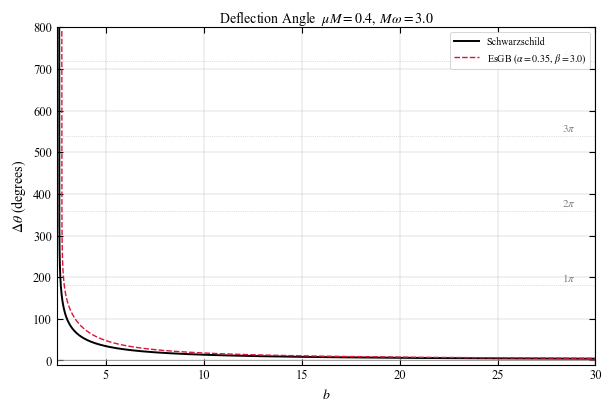

In [1]:
# ══════════════════════════════════════════════════════════════════
# 偏转角 Δθ(b) 计算 + 画图：EsGB vs Schwarzschild
# ══════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import brentq
from scipy.integrate import quad

import esgb_solver_core as core; importlib.reload(core)
from esgb_solver_core import PolynomialCoupling, ExponentialCoupling

rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset' : 'stix',
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 7.5,
    'axes.linewidth'   : 0.8,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'xtick.top'        : True,
    'ytick.right'      : True,
    'lines.linewidth'  : 1.2,
})

# ── 参数设置 ──────────────────────────────────────────────────────
rh         = 1.0
alpha      = 0.35
phi_h_init = 1.183
N          = 19
coupling   = ExponentialCoupling(beta=3.0)

mu_M       = 0.4    # 无量纲粒子质量 μM
M_omega    = 3.0    # 无量纲频率 Mω（仅用于确定 v，需 Mω > μM）

# ── 求解 EsGB 背景 ───────────────────────────────────────────────
sol = core.solve(rh=rh, alpha=alpha, coupling=coupling,
                 phi_h_init=phi_h_init, N=N, verbose=True)
if sol.phi_h < 0:
    sol.phi, sol.Q, sol.phi_h = -sol.phi, -sol.Q, -sol.phi_h
print(sol)

M_adm  = sol.M_ADM
M_schw = rh / 2.0

# 从 μM 和 Mω 计算 v
if mu_M > 0 and M_omega > mu_M:
    v_val = np.sqrt(1.0 - (mu_M / M_omega)**2)
else:
    v_val = 1.0   # 无质量极限
print(f"μM = {mu_M},  Mω = {M_omega},  v = {v_val:.6f}")

# ── Schwarzschild 度规 ────────────────────────────────────────────
A_schw  = lambda r: 1.0 - rh / r
dA_schw = lambda r: rh / r**2
B_schw  = lambda r: 1.0 / (1.0 - rh / r)

# ── solve_rc_bc ───────────────────────────────────────────────────
def solve_rc_bc(A, dA, v, rh):
    w = 1.0 - v**2
    def eq2(r):
        Ar = A(r); dAr = dA(r)
        return r * dAr - 2.0 * Ar * (1.0 - w * Ar)
    r_scan = np.linspace(rh * 1.001, rh * 30.0, 5000)
    f_scan = np.array([eq2(r) for r in r_scan])
    sc = np.where(np.diff(np.sign(f_scan)))[0]
    if len(sc) == 0:
        return np.nan, np.nan, np.nan
    r_c = brentq(eq2, r_scan[sc[0]], r_scan[sc[0]+1], xtol=1e-12)
    Ar_c = A(r_c); factor = 1.0 - w * Ar_c
    if factor <= 0 or v == 0:
        return np.nan, np.nan, np.nan
    bc_sq = r_c**2 / (v**2 * Ar_c) * factor
    if bc_sq < 0:
        return np.nan, np.nan, np.nan
    return r_c, np.sqrt(bc_sq), np.pi * bc_sq

# ── deflection_angle ──────────────────────────────────────────────
def deflection_angle(b, v, A, B, rh):
    """计算偏转角 Δθ(b)，用 u = u0 sin²(t) 变量替换消除端点奇异性。"""
    w = 1.0 - v**2
    u_h = 1.0 / (rh * 1.001)
    def h(u):
        r = 1.0 / u; Ar = A(r); Br = B(r)
        return (1.0 / (v**2 * b**2 * Ar) - u**2 - w / (v**2 * b**2)) / Br
    # 找转折点 u0
    u_scan = np.linspace(1e-8, u_h, 20000)
    h_scan = np.array([h(u) for u in u_scan])
    sc = np.where((h_scan[:-1] > 0) & (h_scan[1:] <= 0))[0]
    if len(sc) == 0:
        return np.nan
    u0 = brentq(h, u_scan[sc[0]], u_scan[sc[0]+1], xtol=1e-14)
    # 变量替换 u = u0 sin²(t)
    def integrand(t):
        if t < 1e-15:
            return 0.0
        u = u0 * np.sin(t)**2
        if u < 1e-15:
            return 0.0
        hval = h(u)
        if hval <= 0:
            return 0.0
        return 2.0 * u0 * np.sin(t) * np.cos(t) / np.sqrt(hval)
    result, _ = quad(integrand, 0, np.pi / 2, limit=200, epsrel=1e-10)
    return 2.0 * result - np.pi

# ── 获取 b_c ─────────────────────────────────────────────────────
rc_e, bc_e, _ = solve_rc_bc(sol.gtt_at, sol.dgtt_dr, v_val, rh)
rc_s, bc_s, _ = solve_rc_bc(A_schw, dA_schw, v_val, rh)
print(f"EsGB:  b_c = {bc_e:.4f},  r_c = {rc_e:.4f},  M_ADM = {M_adm:.4f}")
print(f"Schw:  b_c = {bc_s:.4f},  r_c = {rc_s:.4f},  M     = {M_schw:.4f}")

# ── b 采样：全域对数平滑覆盖，消除断层 ───────────────────────────
b_max = 30.0  # 远场最大采样点，与你图表的 xlim 保持一致

# 计算出距离 b_max 还需要多大的偏移量
max_offset_e = b_max - bc_e
max_offset_s = b_max - bc_s

# 分别生成从 1e-6 到远场边界的对数偏移量
offsets_e = np.logspace(-6, np.log10(max_offset_e), 300)
offsets_s = np.logspace(-6, np.log10(max_offset_s), 300)

# 将偏移量直接叠加到各自的临界撞击参数 b_c 上
b_full_e = bc_e + offsets_e
b_full_s = bc_s + offsets_s

# 合并、去重、排序
b_arr = np.sort(np.unique(np.concatenate([b_full_e, b_full_s])))

# ── 计算偏转角 ───────────────────────────────────────────────────
print("计算 Schwarzschild 偏转角...")
dtheta_schw = np.array([deflection_angle(b, v_val, A_schw, B_schw, rh) for b in b_arr])
print("计算 EsGB 偏转角...")
dtheta_esgb = np.array([deflection_angle(b, v_val, sol.gtt_at, sol.grr_at, rh) for b in b_arr])

# ── 验证牛顿极限 ─────────────────────────────────────────────────
print("\n牛顿极限验证 (大 b):")
for b_test in [20.0, 50.0, 100.0]:
    idx = np.argmin(np.abs(b_arr - b_test))
    # 有质量粒子牛顿偏转角：Δθ = 2M/(bv²)；无质量 v=1 时即 2M/b
    gr_weak_field = (2.0 * M_schw / b_test) * (1.0 + 1.0 / v_val**2)
    print(f"  b={b_test:.0f}: Δθ_Schw={np.degrees(dtheta_schw[idx]):.4f}°, "
      f"GR Weak Field={np.degrees(gr_weak_field):.4f}°")

# ── 画 Δθ(b) ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

mask_s = np.isfinite(dtheta_schw)
mask_e = np.isfinite(dtheta_esgb)

ax.plot(b_arr[mask_s], np.degrees(dtheta_schw[mask_s]),
        color='black', lw=1.4, label='Schwarzschild', zorder=2)
ax.plot(b_arr[mask_e], np.degrees(dtheta_esgb[mask_e]),
        color='#DC143C', lw=1.0, linestyle=(0, (4, 1.5)),
        label=rf'EsGB ($\alpha={alpha},\,{coupling.label_str()}$)', zorder=3)

ax.set_xlabel(r'$b$', fontsize=10)
ax.set_ylabel(r'$\Delta\theta$ (degrees)', fontsize=10)
ax.set_title(rf'Deflection Angle  $\mu M={mu_M},\; M\omega={M_omega}$',
             fontsize=10, pad=3)
ax.set_xlim(min(bc_e, bc_s) * 0.95, 30)
ax.set_ylim(-10, 800)
ax.axhline(0, color='gray', lw=0.5)
for n in range(1, 5):
    ax.axhline(n * 180, color='gray', ls=':', lw=0.5, alpha=0.5)
    ax.text(29, n * 180 + 10, rf'${n}\pi$', fontsize=8, color='gray',
            ha='right')

leg = ax.legend(loc='upper right', framealpha=0.92,
                edgecolor='#cccccc', handlelength=2.5, fontsize=7.2)
leg.get_frame().set_linewidth(0.6)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)
ax.grid(True, which='major', lw=0.3, color='#bbbbbb', zorder=0)

plt.savefig('deflection_angle.pdf', bbox_inches='tight')
plt.savefig('deflection_angle.png', dpi=150, bbox_inches='tight')
print('\nSaved deflection_angle.pdf / .png')
plt.show()

Schwarzschild: 800 个有效角度点
EsGB:          800 个有效角度点
Saved classical_dsigma.pdf / .png


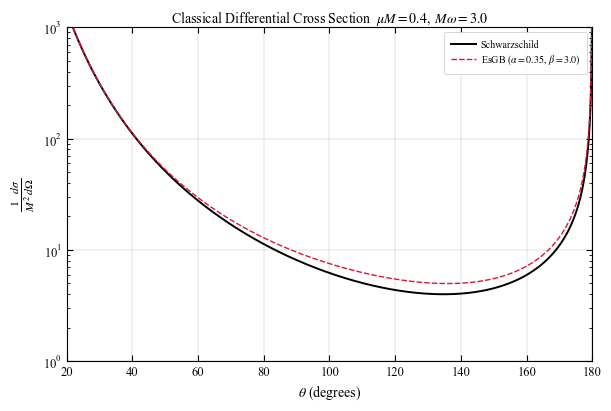

In [8]:
# ══════════════════════════════════════════════════════════════════
# 从 Δθ(b) 计算微分散射截面 dσ/dΩ 并画图
# ══════════════════════════════════════════════════════════════════
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

def fold_to_theta(delta_theta):
    """将偏转角 Δθ fold 到散射角 θ ∈ [0, π]。"""
    th = delta_theta % (2.0 * np.pi)
    return np.where(th > np.pi, 2.0 * np.pi - th, th)

def compute_dsigma(b_arr, dtheta_arr, M_adm, theta_grid=None):
    """
    使用全局未折叠样条法计算微分散射截面。
    完美解决 180 度附近的分支断层/边界撕裂问题。
    """
    if theta_grid is None:
        theta_grid = np.linspace(1.0, 179.9, 800) # 可以放心画到 179.9 度了
        
    theta_grid_rad = np.radians(theta_grid)
    dsigma = np.zeros_like(theta_grid)

    # 1. 过滤无效值
    mask = np.isfinite(dtheta_arr) & (dtheta_arr > 0)
    if np.sum(mask) < 5:
        return theta_grid, dsigma
        
    b_valid  = b_arr[mask]
    dt_valid = dtheta_arr[mask]

    # 2. 按未折叠的偏转角 Δθ 从小到大排序 (此时 b 是从大到小)
    sort_idx  = np.argsort(dt_valid)
    dt_sorted = dt_valid[sort_idx]
    b_sorted  = b_valid[sort_idx]

    # 3. 去重，确保 x 轴严格单调递增，防止样条插值报错
    uniq = np.diff(dt_sorted, prepend=-1) > 1e-10
    dt_sorted = dt_sorted[uniq]
    b_sorted  = b_sorted[uniq]

    if len(dt_sorted) < 5:
        return theta_grid, dsigma

    # 4. 建立唯一的全局样条插值: b = b(Δθ)
    cs    = CubicSpline(dt_sorted, b_sorted, extrapolate=False)
    cs_db = cs.derivative()

    dt_max = dt_sorted[-1]
    dt_min = dt_sorted[0]
    
    # 理论最大绕转圈数
    N_max = int(dt_max / (2.0 * np.pi)) + 1

    for n in range(N_max + 1):
        # ── 分支 1：前向绕转 (Δθ = 2nπ + θ) ──
        dt_fwd = 2.0 * n * np.pi + theta_grid_rad
        mask_fwd = (dt_fwd >= dt_min) & (dt_fwd <= dt_max)
        if np.any(mask_fwd):
            th_eval = dt_fwd[mask_fwd]
            bk      = cs(th_eval)
            dbdth   = cs_db(th_eval)
            sin_th  = np.sin(theta_grid_rad[mask_fwd])
            
            # 排除数值发散点
            phys_mask = (np.abs(dbdth) > 1e-14) & (sin_th > 1e-10) & np.isfinite(bk)
            if np.any(phys_mask):
                term = (np.abs(bk[phys_mask]) / sin_th[phys_mask] * np.abs(dbdth[phys_mask])) / M_adm**2
                idx_to_update = np.where(mask_fwd)[0][phys_mask]
                dsigma[idx_to_update] += term

        # ── 分支 2：后向绕转 (Δθ = 2(n+1)π - θ) ──
        dt_bwd = 2.0 * (n + 1) * np.pi - theta_grid_rad
        mask_bwd = (dt_bwd >= dt_min) & (dt_bwd <= dt_max)
        if np.any(mask_bwd):
            th_eval = dt_bwd[mask_bwd]
            bk      = cs(th_eval)
            dbdth   = cs_db(th_eval)
            sin_th  = np.sin(theta_grid_rad[mask_bwd])
            
            # 排除数值发散点
            phys_mask = (np.abs(dbdth) > 1e-14) & (sin_th > 1e-10) & np.isfinite(bk)
            if np.any(phys_mask):
                term = (np.abs(bk[phys_mask]) / sin_th[phys_mask] * np.abs(dbdth[phys_mask])) / M_adm**2
                idx_to_update = np.where(mask_bwd)[0][phys_mask]
                dsigma[idx_to_update] += term

    return theta_grid, dsigma

# ── 计算 ─────────────────────────────────────────────────────────
# 如果需要局部放大，可以直接传入自定义的 theta_grid
# 例如：custom_grid = np.linspace(150, 180, 500)
theta_s, dsigma_s = compute_dsigma(b_arr, dtheta_schw, M_schw)
theta_e, dsigma_e = compute_dsigma(b_arr, dtheta_esgb, M_adm)

print(f"Schwarzschild: {np.sum(dsigma_s > 0)} 个有效角度点")
print(f"EsGB:          {np.sum(dsigma_e > 0)} 个有效角度点")

# ── 画图 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

mask_s = dsigma_s > 0
mask_e = dsigma_e > 0

ax.semilogy(theta_s[mask_s], dsigma_s[mask_s],
            color='black', lw=1.4, linestyle='-',
            label='Schwarzschild', zorder=2)
ax.semilogy(theta_e[mask_e], dsigma_e[mask_e],
            color='#DC143C', lw=1.0, linestyle=(0, (4, 1.5)),
            label=rf'EsGB ($\alpha={alpha},\,{coupling.label_str()}$)',
            zorder=3)

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=10)
ax.set_ylabel(r'$\frac{1}{M^2}\frac{d\sigma}{d\Omega}$', fontsize=12)
ax.set_title(rf'Classical Differential Cross Section  $\mu M={mu_M},\; M\omega={M_omega}$',
             fontsize=10, pad=3)
ax.set_xlim(20, 180)
ax.set_ylim(1e0, 1e3)  # 稍微放宽下限，保留高阶弱信号

leg = ax.legend(loc='upper right', framealpha=0.92,
                edgecolor='#cccccc', handlelength=2.5,
                borderpad=0.7, labelspacing=0.38, handletextpad=0.5,
                fontsize=7.2)
leg.get_frame().set_linewidth(0.6)

ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)
ax.grid(True, which='major', lw=0.3, color='#bbbbbb', zorder=0)

plt.savefig('classical_dsigma.pdf', bbox_inches='tight')
plt.savefig('classical_dsigma.png', dpi=150, bbox_inches='tight')
print('Saved classical_dsigma.pdf / .png')
plt.show()

# 多组 EsGB 解 vs Schwarzschild：偏转角 & 微分散射截面

In [10]:
# ══════════════════════════════════════════════════════════════════
# 偏转角 Δθ(b) + 微分散射截面 dσ/dΩ 多组对比图
# ══════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings("ignore")
import importlib
import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import brentq
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

import esgb_solver_core as core; importlib.reload(core)
from esgb_solver_core import PolynomialCoupling, ExponentialCoupling

rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset' : 'stix',
    'axes.labelsize'   : 10,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 7.5,
    'axes.linewidth'   : 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction'  : 'in',
    'ytick.direction'  : 'in',
    'xtick.top'        : True,
    'ytick.right'      : True,
    'lines.linewidth'  : 1.2,
})

# ── 参数设置 ──────────────────────────────────────────────────────
CASES = [
    dict(alpha=0.100, coupling=ExponentialCoupling(beta=3.0), phi_h_init=0.797),
    dict(alpha=0.350, coupling=ExponentialCoupling(beta=3.0), phi_h_init=1.183),
    dict(alpha=0.600, coupling=ExponentialCoupling(beta=3.0), phi_h_init=1.301),
]
rh    = 1.0
N     = 19
mu_M  = 0.4       # 无量纲粒子质量 μM
M_omega = 3.0     # 无量纲频率 Mω（需 Mω > μM）

# ── 绘图样式 ──────────────────────────────────────────────────────
_COLORS = ['#DAA520', '#228B22', '#DC143C']
_DASHES = [(6, 2), (4, 1.5), (2, 1.5)]
_LW_SOL = 1.0
_LW_REF = 1.4

def _ls(i):
    return dict(color=_COLORS[i], lw=_LW_SOL, linestyle=(0, _DASHES[i]))

def _ls_schw():
    return dict(color='black', lw=_LW_REF, linestyle='-')

# ── 工具函数 ──────────────────────────────────────────────────────
def solve_rc_bc(A, dA, v, rh):
    w = 1.0 - v**2
    def eq2(r):
        Ar = A(r); dAr = dA(r)
        return r * dAr - 2.0 * Ar * (1.0 - w * Ar)
    r_scan = np.linspace(rh * 1.001, rh * 30.0, 5000)
    f_scan = np.array([eq2(r) for r in r_scan])
    sc = np.where(np.diff(np.sign(f_scan)))[0]
    if len(sc) == 0:
        return np.nan, np.nan, np.nan
    r_c = brentq(eq2, r_scan[sc[0]], r_scan[sc[0]+1], xtol=1e-12)
    Ar_c = A(r_c); factor = 1.0 - w * Ar_c
    if factor <= 0 or v == 0:
        return np.nan, np.nan, np.nan
    bc_sq = r_c**2 / (v**2 * Ar_c) * factor
    if bc_sq < 0:
        return np.nan, np.nan, np.nan
    return r_c, np.sqrt(bc_sq), np.pi * bc_sq

def deflection_angle(b, v, A, B, rh):
    w = 1.0 - v**2
    def h(u):
        r = 1.0 / u; Ar = A(r); Br = B(r)
        return (1.0 / (v**2 * b**2 * Ar) - u**2 - w / (v**2 * b**2)) / Br
    u_h = 1.0 / (rh * 1.001)
    u_scan = np.linspace(1e-8, u_h, 20000)
    h_scan = np.array([h(u) for u in u_scan])
    sc = np.where((h_scan[:-1] > 0) & (h_scan[1:] <= 0))[0]
    if len(sc) == 0:
        return np.nan
    u0 = brentq(h, u_scan[sc[0]], u_scan[sc[0]+1], xtol=1e-14)
    def integrand(t):
        if t < 1e-15:
            return 0.0
        u = u0 * np.sin(t)**2
        if u < 1e-15:
            return 0.0
        hval = h(u)
        if hval <= 0:
            return 0.0
        return 2.0 * u0 * np.sin(t) * np.cos(t) / np.sqrt(hval)
    result, _ = quad(integrand, 0, np.pi / 2, limit=200, epsrel=1e-10)
    return 2.0 * result - np.pi

def compute_dsigma(b_arr, dtheta_arr, M_adm, theta_grid=None):
    if theta_grid is None:
        theta_grid = np.linspace(1.0, 179.9, 800)
    theta_grid_rad = np.radians(theta_grid)
    dsigma = np.zeros_like(theta_grid)
    mask = np.isfinite(dtheta_arr) & (dtheta_arr > 0)
    if np.sum(mask) < 5:
        return theta_grid, dsigma
    b_valid  = b_arr[mask]
    dt_valid = dtheta_arr[mask]
    sort_idx  = np.argsort(dt_valid)
    dt_sorted = dt_valid[sort_idx]
    b_sorted  = b_valid[sort_idx]
    uniq = np.diff(dt_sorted, prepend=-1) > 1e-10
    dt_sorted = dt_sorted[uniq]
    b_sorted  = b_sorted[uniq]
    if len(dt_sorted) < 5:
        return theta_grid, dsigma
    cs    = CubicSpline(dt_sorted, b_sorted, extrapolate=False)
    cs_db = cs.derivative()
    dt_max = dt_sorted[-1]; dt_min = dt_sorted[0]
    N_max = int(dt_max / (2.0 * np.pi)) + 1
    for n in range(N_max + 1):
        dt_fwd = 2.0 * n * np.pi + theta_grid_rad
        mask_fwd = (dt_fwd >= dt_min) & (dt_fwd <= dt_max)
        if np.any(mask_fwd):
            th_eval = dt_fwd[mask_fwd]
            bk      = cs(th_eval)
            dbdth   = cs_db(th_eval)
            sin_th  = np.sin(theta_grid_rad[mask_fwd])
            phys_mask = (np.abs(dbdth) > 1e-14) & (sin_th > 1e-10) & np.isfinite(bk)
            if np.any(phys_mask):
                term = (np.abs(bk[phys_mask]) / sin_th[phys_mask] * np.abs(dbdth[phys_mask])) / M_adm**2
                idx_to_update = np.where(mask_fwd)[0][phys_mask]
                dsigma[idx_to_update] += term
        dt_bwd = 2.0 * (n + 1) * np.pi - theta_grid_rad
        mask_bwd = (dt_bwd >= dt_min) & (dt_bwd <= dt_max)
        if np.any(mask_bwd):
            th_eval = dt_bwd[mask_bwd]
            bk      = cs(th_eval)
            dbdth   = cs_db(th_eval)
            sin_th  = np.sin(theta_grid_rad[mask_bwd])
            phys_mask = (np.abs(dbdth) > 1e-14) & (sin_th > 1e-10) & np.isfinite(bk)
            if np.any(phys_mask):
                term = (np.abs(bk[phys_mask]) / sin_th[phys_mask] * np.abs(dbdth[phys_mask])) / M_adm**2
                idx_to_update = np.where(mask_bwd)[0][phys_mask]
                dsigma[idx_to_update] += term
    return theta_grid, dsigma

# ── Schwarzschild 度规 ────────────────────────────────────────────
M_schw  = rh / 2.0
A_schw  = lambda r: 1.0 - rh / r
dA_schw = lambda r: rh / r**2
B_schw  = lambda r: 1.0 / (1.0 - rh / r)

# ── 从 μM 和 Mω 计算 v ───────────────────────────────────────────
if mu_M > 0 and M_omega > mu_M:
    v_val = np.sqrt(1.0 - (mu_M / M_omega)**2)
else:
    v_val = 1.0
print(f"μM = {mu_M},  Mω = {M_omega},  v = {v_val:.6f}")

# ── 求解多组 EsGB 背景 ───────────────────────────────────────────
solutions = []
for kw in CASES:
    sol = core.solve(rh=rh, N=N, verbose=True, **kw)
    if sol.phi_h < 0:
        sol.phi, sol.Q, sol.phi_h = -sol.phi, -sol.Q, -sol.phi_h
    sol.label = (f'$\\alpha={sol.alpha},\\,{sol.coupling.label_str()}$'
                 f'  ($\\phi_h={sol.phi_h:.3f}$)')
    solutions.append(sol)

# ── 获取各解的 b_c ────────────────────────────────────────────────
rc_s, bc_s, _ = solve_rc_bc(A_schw, dA_schw, v_val, rh)
bc_list = [bc_s]
for sol in solutions:
    rc_e, bc_e, _ = solve_rc_bc(sol.gtt_at, sol.dgtt_dr, v_val, rh)
    bc_list.append(bc_e)
    print(f"{sol.label}:  b_c = {bc_e:.4f},  M_ADM = {sol.M_ADM:.4f}")
print(f"Schwarzschild:  b_c = {bc_s:.4f},  M = {M_schw:.4f}")

# ── b 采样 ───────────────────────────────────────────────────────
b_max = 30.0
all_offsets = []
for bc in bc_list:
    if np.isfinite(bc):
        max_off = b_max - bc
        all_offsets.append(bc + np.logspace(-6, np.log10(max_off), 300))
b_arr = np.sort(np.unique(np.concatenate(all_offsets)))

# ── 计算偏转角 ───────────────────────────────────────────────────
print("计算 Schwarzschild 偏转角...")
dtheta_schw = np.array([deflection_angle(b, v_val, A_schw, B_schw, rh) for b in b_arr])

dtheta_esgb_list = []
for i, sol in enumerate(solutions):
    print(f"计算 EsGB 偏转角 ({i+1}/{len(solutions)})...")
    dt = np.array([deflection_angle(b, v_val, sol.gtt_at, sol.grr_at, rh) for b in b_arr])
    dtheta_esgb_list.append(dt)

# ── 计算微分散射截面 ─────────────────────────────────────────────
theta_s, dsigma_s = compute_dsigma(b_arr, dtheta_schw, M_schw)
dsigma_esgb_list = []
for sol, dt in zip(solutions, dtheta_esgb_list):
    th, ds = compute_dsigma(b_arr, dt, sol.M_ADM)
    dsigma_esgb_list.append((th, ds))

# ══════════════════════════════════════════════════════════════════
# 图1：偏转角 Δθ(b)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

mask_s = np.isfinite(dtheta_schw)
ax.plot(b_arr[mask_s], np.degrees(dtheta_schw[mask_s]),
        label='Schwarzschild', **_ls_schw(), zorder=2)

for i, (sol, dt) in enumerate(zip(solutions, dtheta_esgb_list)):
    mask_e = np.isfinite(dt)
    ax.plot(b_arr[mask_e], np.degrees(dt[mask_e]),
            label=sol.label, **_ls(i), zorder=3)

ax.set_xlabel(r'$b$', fontsize=10)
ax.set_ylabel(r'$\Delta\theta$ (degrees)', fontsize=10)
ax.set_title(rf'Deflection Angle  $\mu M={mu_M},\; M\omega={M_omega}$',
             fontsize=10, pad=3)
ax.set_xlim(min(bc for bc in bc_list if np.isfinite(bc)) * 0.95, 30)
ax.set_ylim(-10, 800)
ax.axhline(0, color='gray', lw=0.5)
for n in range(1, 5):
    ax.axhline(n * 180, color='gray', ls=':', lw=0.5, alpha=0.5)
    ax.text(29, n * 180 + 10, rf'${n}\pi$', fontsize=8, color='gray',
            ha='right')

leg = ax.legend(loc='upper right', framealpha=0.92,
                edgecolor='#cccccc', handlelength=2.5,
                borderpad=0.7, labelspacing=0.38, handletextpad=0.5,
                fontsize=7.2)
leg.get_frame().set_linewidth(0.6)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)
ax.grid(True, which='major', lw=0.3, color='#bbbbbb', zorder=0)

plt.savefig('deflection_angle_comparison.pdf', bbox_inches='tight')
plt.savefig('deflection_angle_comparison.png', dpi=150, bbox_inches='tight')
print('\nSaved deflection_angle_comparison.pdf / .png')
plt.show()

# ══════════════════════════════════════════════════════════════════
# 图2：微分散射截面 dσ/dΩ
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

mask_s = dsigma_s > 0
ax.semilogy(theta_s[mask_s], dsigma_s[mask_s],
            label='Schwarzschild', **_ls_schw(), zorder=2)

for i, (sol, (th, ds)) in enumerate(zip(solutions, dsigma_esgb_list)):
    mask_e = ds > 0
    ax.semilogy(th[mask_e], ds[mask_e],
                label=sol.label, **_ls(i), zorder=3)

ax.set_xlabel(r'$\theta$ (degrees)', fontsize=10)
ax.set_ylabel(r'$\frac{1}{M^2}\frac{d\sigma}{d\Omega}$', fontsize=12)
ax.set_title(rf'Classical Differential Cross Section  $\mu M={mu_M},\; M\omega={M_omega}$',
             fontsize=10, pad=3)
ax.set_xlim(20, 180)
ax.set_ylim(1e0, 1e3)

leg = ax.legend(loc='upper right', framealpha=0.92,
                edgecolor='#cccccc', handlelength=2.5,
                borderpad=0.7, labelspacing=0.38, handletextpad=0.5,
                fontsize=7.2)
leg.get_frame().set_linewidth(0.6)
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)
ax.grid(True, which='major', lw=0.3, color='#bbbbbb', zorder=0)

plt.savefig('geodesic_dsigma_comparison.pdf', bbox_inches='tight')
plt.savefig('geodesic_dsigma_comparison.png', dpi=150, bbox_inches='tight')
print('Saved geodesic_dsigma_comparison.pdf / .png')
plt.show()

μM = 0.4,  Mω = 3.0,  v = 0.991071
[OK]  alpha=0.1, ExponentialCoupling(beta=3.0), phi_h=0.80095, M=0.55799, Q=0.45821, ||R||=3.79e-12
[OK]  alpha=0.35, ExponentialCoupling(beta=3.0), phi_h=1.10297, M=0.62516, Q=0.83384, ||R||=8.59e-13
[OK]  alpha=0.6, ExponentialCoupling(beta=3.0), phi_h=1.20305, M=0.65935, Q=1.01354, ||R||=1.66e-13
$\alpha=0.1,\,\beta=3.0$  ($\phi_h=0.801$):  b_c = 2.8012,  M_ADM = 0.5580
$\alpha=0.35,\,\beta=3.0$  ($\phi_h=1.103$):  b_c = 2.7466,  M_ADM = 0.6252
$\alpha=0.6,\,\beta=3.0$  ($\phi_h=1.203$):  b_c = 2.6531,  M_ADM = 0.6593
Schwarzschild:  b_c = 2.6137,  M = 0.5000
计算 Schwarzschild 偏转角...
计算 EsGB 偏转角 (1/3)...
计算 EsGB 偏转角 (2/3)...
计算 EsGB 偏转角 (3/3)...

Saved deflection_angle_comparison.pdf / .png
Saved geodesic_dsigma_comparison.pdf / .png
